# **Extended Data Figure 3**
Reproduces panels of Extended Data Figure 3 from simulation data. Data used:
- `DNg100_Stim_CoreCPG/hyak/run_id=29278022` (**a**)
- `DNg100_Stim_CoreCPG/hyak/run_id=29236830`(**f**)

In [ ]:
dataPath = "/data/users/smpuglie/published-simulations/"

In [1]:
import matplotlib.pyplot as plt
from src.utils.plot_utils import *
from src.utils.sim_utils import *
import yaml
import numpy as np
import jax.numpy as jnp
import sparse
from hydra import initialize, compose
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
from pathlib import Path, PosixPath
import h5py

# # PLOT defaults
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.spines.right"] = "False"
plt.rcParams["axes.spines.top"] = "False"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["figure.figsize"] = (2,2)
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams["xtick.major.size"] = 1.7
plt.rcParams["xtick.minor.size"] = 1.0
plt.rcParams["ytick.major.size"] = 1.7
plt.rcParams["xtick.major.width"] = 0.25
plt.rcParams["xtick.minor.width"] = 0.18
plt.rcParams["ytick.major.width"] = 0.25
plt.rcParams["figure.dpi"] = 200

plt.rcParams["axes.labelpad"] = 1.5
plt.rcParams["xtick.major.pad"] = 1.5
plt.rcParams["ytick.major.pad"] = 1.5

SMALL_SIZE = 6
LABEL_SIZE = 7
AXLABEL_SIZE = 8
TITLE_SIZE = 10

plt.rcParams["font.family"] = "Arial" # "Arial"
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=TITLE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXLABEL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=LABEL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

moduleColors = get_module_colors()

dnColor = "#51bbad"
excColor = "#d84a2e"
inhColor = "#026b85"
mnColor = "#267655"
lightDnColor = "#a7dcd5ff"
lightExcColor = "#ff9985"
lightInhColor = "#00acd6"
connColormap = sns.blend_palette([inhColor,lightInhColor,"white",lightExcColor,excColor],as_cmap=True)

Using diffeqsolve-based neural simulation (original)


# MANC DNg100 core CPG only $|I_\text{stim}|$ sweep

In [ ]:
simType = "DNg100_Stim_CoreCPG"
simPath = simType+"/hyak/run_id=29278022"
folder = dataPath + simPath
overallParams = DictConfig(load_from_yaml(folder+"/multirun.yaml"))
wTable = pd.read_csv("../"+overallParams.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nSims = overallParams.experiment.n_replicates

/home/smpuglie/Pugliese_2025/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## load for the first time

In [ ]:
nActive = pd.DataFrame(index=np.arange(nSims))
nMnsActive = pd.DataFrame(index=np.arange(nSims))
simScore = pd.DataFrame(index=np.arange(nSims))
mnFreq = pd.DataFrame(index=np.arange(nSims))

subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)

for subfolder in subfolders:
    print(f"Loading {subfolder}")
    Rs = sparse.load_npz(folder+f"/{subfolder}/ckpt/{simType}_Rs.npz").todense()
    dataset = 0
    Rs = Rs[dataset]
    params = DictConfig(load_from_yaml(folder+f"/{subfolder}/.hydra/config.yaml"))
    stimI = params.experiment.stimI[0]
    for i in range(nSims):
        # active neurons
        R = Rs[i]
        
        nActive.loc[i,stimI] = sum(np.max(R,1)>0.01)
        activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        nMnsActive.loc[i,stimI] = np.sum(activeMnsMask)
        activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
        score, freq = compute_oscillation_score(R[...,250:],activeMnsMaskPastTransient)
        simScore.loc[i,stimI] = score
        mnFreq.loc[i,stimI] = freq

nActive = nActive.transpose().sort_index().transpose()
nMnsActive = nMnsActive.transpose().sort_index().transpose()
simScore = simScore.transpose().sort_index().transpose()
mnFreq = mnFreq.transpose().sort_index().transpose()

figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

Loading experiment.seed=207,experiment.stimI=[300]
Loading experiment.seed=207,experiment.stimI=[340]
Loading experiment.seed=207,experiment.stimI=[180]
Loading experiment.seed=207,experiment.stimI=[260]
Loading experiment.seed=207,experiment.stimI=[220]


In [ ]:
if not os.path.exists(figFolder):
    os.makedirs(figFolder)
nActive.to_csv(figFolder+"/nActive.csv")
nMnsActive.to_csv(figFolder+"/nMnsActive.csv")
simScore.to_csv(figFolder+"/scores.csv")
mnFreq.to_csv(figFolder+"/frequencies.csv")

## reload and plot

In [ ]:
figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

nMnsActive = pd.read_csv(figFolder+"/nMnsActive.csv",index_col=0)
simScore = pd.read_csv(figFolder+"/scores.csv",index_col=0)
mnFreq = pd.read_csv(figFolder+"/frequencies.csv",index_col=0)

In [ ]:
mnFreq_plotShape = (mnFreq/overallParams.sim.dt).iloc[:,1:].astype(float).melt(var_name="stimI",value_name="frequency")
nMnsActive_plotShape = nMnsActive.iloc[:,1:].astype(float).melt(var_name="stimI",value_name="nMnsActive")

plt.figure(figsize=(0.84,1.426))
sns.violinplot(mnFreq_plotShape.loc[nMnsActive_plotShape["nMnsActive"]>0],x="stimI",y="frequency",edgecolor=None,inner=None,cut=0,alpha=0.5,color=mnColor,width=0.9)
sns.boxplot(mnFreq_plotShape.loc[nMnsActive_plotShape["nMnsActive"]>0],x="stimI",y="frequency",width=0.2,linewidth=0.5,fliersize=2**0.75,
            boxprops={"alpha":1.0,},showfliers=False,color=mnColor)
plt.gca().tick_params(axis='x', labelrotation=45)
sns.despine(offset=2)

plt.xlabel("|input to DNg100|")
plt.ylabel("motor neuron\nfrequency (Hz)")
# plt.gcf().set_dpi(500)
plt.ylim([0,22])

if not os.path.exists(figFolder):
    os.makedirs(figFolder)
plt.savefig(figFolder+f"/mnFreqViolin_activeMnsOnly.svg",transparent=True)
plt.show()

# Connectivity plots: core CPG neurons in all 4 datasets

In [2]:
figFolder = "../figures/minicircuit-plots"

## MANC

/tmp/ipykernel_965883/2759031451.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["circuitSide"] = miniData["somaSide"]
/tmp/ipykernel_965883/2759031451.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the 

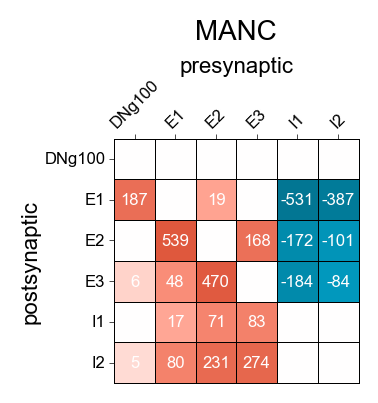

In [3]:
W = load_W("../data/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv")
wTable = load_wTable("../data/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv")

miniTypes = ["DNg100","IN17A001","INXXX466","IN19B012","IN16B036","IN19A007"]
ticklabels = ["DNg100","E1","E2","E3","I1","I2"]

miniData = wTable.loc[wTable["type"].isin(miniTypes)]

miniData["circuitSide"] = miniData["somaSide"]
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="LHS")] = "RHS"
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="RHS")] = "LHS"
miniData.loc[[31,132],"circuitSide"] = ["LHS","RHS"]

fig = plt.figure()
side = "LHS"
legMiniData = miniData.loc[(miniData["circuitSide"]==side)]

legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes)
legMiniData.sort_values("type",inplace=True)
miniW = W[np.ix_(legMiniData.index,legMiniData.index)]

connColorMap = sns.blend_palette(["#026b85","#00acd6","white","#ff9985","#d84a2e"],as_cmap=True)
ax = sns.heatmap(miniW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
            cmap=connColorMap,square=True,
            xticklabels=ticklabels,yticklabels=ticklabels,
            linewidths=0.25, linecolor='black',
            annot=True,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColorMap(0.5)})
# fig = plt.gcf()
ax.tick_params("x",labelrotation=45)
ax.tick_params("y",labelrotation=0)
plt.xlabel("presynaptic")
plt.ylabel("postsynaptic")
plt.title("MANC",fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
fig.set_figheight(2.0)
fig.set_figwidth(2.0)
plt.tight_layout()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/MANC_ins.svg",transparent=True)
plt.show()

## FANC

/tmp/ipykernel_965883/4033276511.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["pt_supervoxel_id"] = pd.Categorical(miniData["pt_supervoxel_id"],categories=miniSvids)
/tmp/ipykernel_965883/4033276511.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData.sort_values("pt_supervoxel_id",inplace=True)


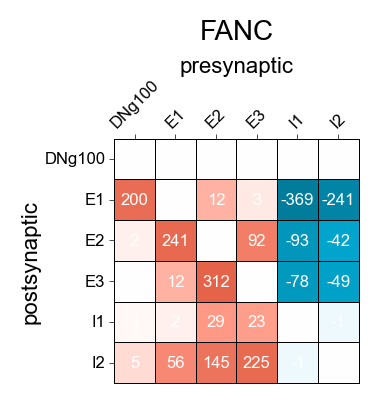

In [4]:
W = load_W("../data/fanc t1l connectome data/W_BDN2toMN_20250107_corrected.npy")
wTable = load_wTable("../data/fanc t1l connectome data/wTable_BDN2toMN_20250107_corrected.csv")

miniSvids = [73115599907537415,72834674820722635,72975481296715415,73820799177797612,72905112619913957,72483380721505294]
ticklabels = ["DNg100","E1","E2","E3","I1","I2"]

miniData = wTable.loc[wTable["pt_supervoxel_id"].isin(miniSvids)]

fig = plt.figure()

miniData["pt_supervoxel_id"] = pd.Categorical(miniData["pt_supervoxel_id"],categories=miniSvids)
miniData.sort_values("pt_supervoxel_id",inplace=True)
miniW = W[np.ix_(miniData.index,miniData.index)]

connColorMap = sns.blend_palette(["#026b85","#00acd6","white","#ff9985","#d84a2e"],as_cmap=True)
ax = sns.heatmap(miniW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
            cmap=connColorMap,square=True,
            xticklabels=ticklabels,yticklabels=ticklabels,
            linewidths=0.25, linecolor='black',
            annot=True,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColorMap(0.5)})
# fig = plt.gcf()
ax.tick_params("x",labelrotation=45)
ax.tick_params("y",labelrotation=0)
plt.xlabel("presynaptic")
plt.ylabel("postsynaptic")
plt.title("FANC",fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
fig.set_figheight(2.0)
fig.set_figwidth(2.0)
plt.tight_layout()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/FANC_ins.svg",transparent=True)
plt.show()

## Male CNS

/tmp/ipykernel_965883/2497781155.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["circuitSide"] = miniData["somaSide"]
/tmp/ipykernel_965883/2497781155.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the

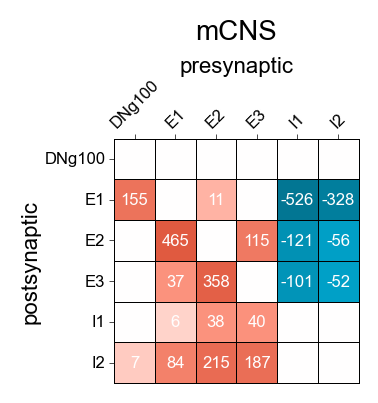

In [6]:
W = load_W("../data/imac t1 connectome data/W_20260210_vncRoisOnly.csv")
wTable = load_wTable("../data/imac t1 connectome data/wTable_20260210_vncRoisOnly.csv")

# miniTypes = ["DNg100","IN17A001","INXXX466","IN19B012","IN03A006","INXXX464","IN16B036","IN19A007"]
miniTypes = ["DNg100","IN17A001","INXXX466","IN19B012","IN16B036","IN19A007"]
ticklabels = ["DNg100","E1","E2","E3","I1","I2"]

miniData = wTable.loc[wTable["type"].isin(miniTypes)]

miniData["circuitSide"] = miniData["somaSide"]
miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="L")] = "R"
miniData["circuitSide"].loc[(miniData["subclass"]=="xl")&(miniData["somaSide"]=="L")] = "R"

miniData["circuitSide"].loc[(miniData["subclass"]=="BR")&(miniData["somaSide"]=="R")] = "L"
miniData["circuitSide"].loc[(miniData["subclass"]=="xl")&(miniData["somaSide"]=="R")] = "L"

fig = plt.figure()
side = "L"

legMiniData = miniData.loc[(miniData["circuitSide"]==side)]

legMiniData["type"] = pd.Categorical(legMiniData["type"],categories=miniTypes)
legMiniData.sort_values("type",inplace=True)
miniW = W[np.ix_(legMiniData.index,legMiniData.index)]

connColorMap = sns.blend_palette(["#026b85","#00acd6","white","#ff9985","#d84a2e"],as_cmap=True)
ax = sns.heatmap(miniW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
            cmap=connColorMap,square=True,
            xticklabels=ticklabels,yticklabels=ticklabels,
            linewidths=0.25, linecolor='black',
            annot=True,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColorMap(0.5)})
ax.tick_params("x",labelrotation=45)
ax.tick_params("y",labelrotation=0)
plt.xlabel("presynaptic")
plt.ylabel("postsynaptic")
plt.title("mCNS",fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
fig.set_figheight(2.0)
fig.set_figwidth(2.0)
plt.tight_layout()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/IMAC_ins.svg",transparent=True)
plt.show()

## BANC

/tmp/ipykernel_965883/4012229619.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miniData["circuitSide"] = miniData["side"]
/tmp/ipykernel_965883/4012229619.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assi

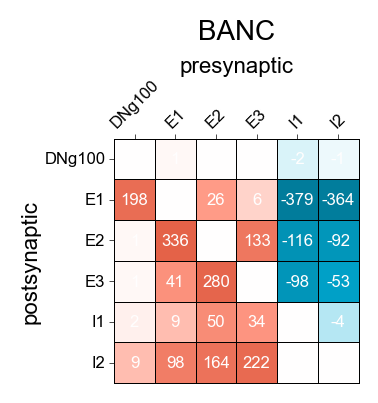

In [7]:
W = load_W("../data/banc t1 premotor/W_20260217.npz")
wTable = load_wTable("../data/banc t1 premotor/wTable_20260217_fullData_consistentColumns.csv")

miniTypes = ["DNg100","IN17A001","INXXX466","IN19B012","IN16B036","IN19A007"]
ticklabels = ["DNg100","E1","E2","E3","I1","I2"]

miniData = wTable.loc[wTable["cell_type"].isin(miniTypes)]

miniData["circuitSide"] = miniData["side"]
miniData["circuitSide"].loc[(miniData["cell_type"]=="IN19B012")&(miniData["side"]=="left")] = "right"
miniData["circuitSide"].loc[(miniData["cell_type"]=="DNg100")&(miniData["side"]=="left")] = "right"

miniData["circuitSide"].loc[(miniData["cell_type"]=="IN19B012")&(miniData["side"]=="right")] = "left"
miniData["circuitSide"].loc[(miniData["cell_type"]=="DNg100")&(miniData["side"]=="right")] = "left"

fig = plt.figure()
side = "left"

legMiniData = miniData.loc[(miniData["circuitSide"]==side)]

legMiniData["cell_type"] = pd.Categorical(legMiniData["cell_type"],categories=miniTypes)
legMiniData.sort_values("cell_type",inplace=True)
miniW = W[np.ix_(legMiniData.index,legMiniData.index)]

connColorMap = sns.blend_palette(["#026b85","#00acd6","white","#ff9985","#d84a2e"],as_cmap=True)
ax = sns.heatmap(miniW.T,norm = colors.SymLogNorm(10,vmin=-1000,vmax=1000),
            cmap=connColorMap,square=True,
            xticklabels=ticklabels,yticklabels=ticklabels,
            linewidths=0.25, linecolor='black',
            annot=True,fmt=".0f",clip_on=False,cbar=False,annot_kws={"fontsize":6,"color":connColorMap(0.5)})
# fig = plt.gcf()
ax.tick_params("x",labelrotation=45)
ax.tick_params("y",labelrotation=0)
plt.xlabel("presynaptic")
plt.ylabel("postsynaptic")
plt.title("BANC",fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 
fig.set_figheight(2.0)
fig.set_figwidth(2.0)
plt.tight_layout()

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/BANC_ins.svg",transparent=True)
plt.show()

# MANC 1024x core CPG only

In [ ]:
simType = "DNg100_Stim_CoreCPG"
simPath = simType+"/hyak/run_id=29236830"
folder = dataPath + simPath
subfolders = []
for f in os.listdir(folder):
    if os.path.isdir(f"{folder}/{f}"):
        subfolders.append(f)
params = DictConfig(load_from_yaml(folder+"/multirun.yaml"))

dataset = 0

Rs = None

for subfolder in subfolders:
    if Rs is None:
        Rs = sparse.load_npz(f"{folder}/{subfolder}/ckpt/{simType}_Rs.npz").todense()
        Rs = Rs[dataset]
    else:
        batchRs = sparse.load_npz(f"{folder}/{subfolder}/ckpt/{simType}_Rs.npz").todense()
        batchRs = batchRs[dataset]
        Rs = np.concatenate([Rs,batchRs],axis=0)
        del batchRs
    
nSims = Rs.shape[0]

wTable = pd.read_csv("../"+params.experiment["dfPath"].split("Pugliese_2025")[1])
mnData = sort_motor_modules(wTable.loc[wTable["motor module"].notna()])
nMnsActive = pd.Series(index=np.arange(nSims))
simScore = pd.Series(index=np.arange(nSims))

for i in range(nSims):
    R = Rs[i]
    
    activeMnsMask = (np.max(R,1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    nMnsActive.loc[i] = np.sum(activeMnsMask)
    activeMnsMaskPastTransient = (np.max(R[:,250:],1)>0.01) & (jnp.isin(jnp.arange(R.shape[0]), mnData.index.to_numpy()))
    score, _ = compute_oscillation_score(R[:,250:],activeMnsMaskPastTransient)
    simScore.loc[i] = score
    
figFolder = "../figures/"
figFolder += "-".join(str.split(simPath,"/"))

/home/smpuglie/vnc-connectome-sim/src/utils/plot_utils.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neuronData[colName] = pd.Categorical(neuronData[colName],categories=["coxa swing", "coxa stance", "femur/tr extend", "femur/tr flex",


## individual traces (main figure 3h)

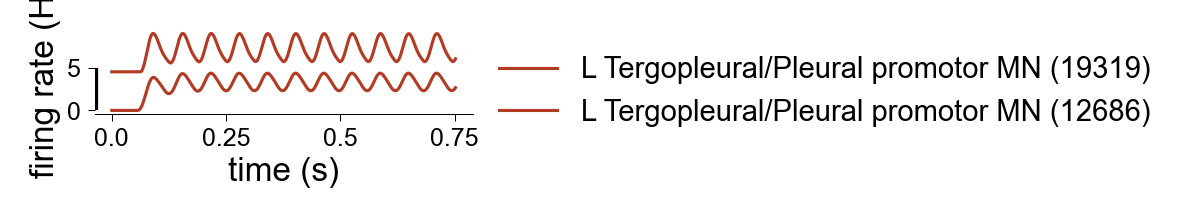

In [ ]:
idx = 901 #np.random.randint(nSims)
spacer = 4.5
scalebar = 5

timeLimit = .75

R = Rs[idx]

plt.figure()
ax = plot_R_traces_stacked_by_module(R[:,:750],mnData,activeOnly=True,space=spacer)
add_tAxis(ax,timeLimit,3.00001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,scalebar,"k")
plt.yticks([0,scalebar])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
fig = plt.gcf()
ax.grid(False)
plt.xlabel("time (s)")


fig.set_figwidth(1.626)
fig.set_figheight(1.1/3)
fig.set_dpi(300)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/mnTraces_idx{idx}.svg",transparent=True)
plt.show()

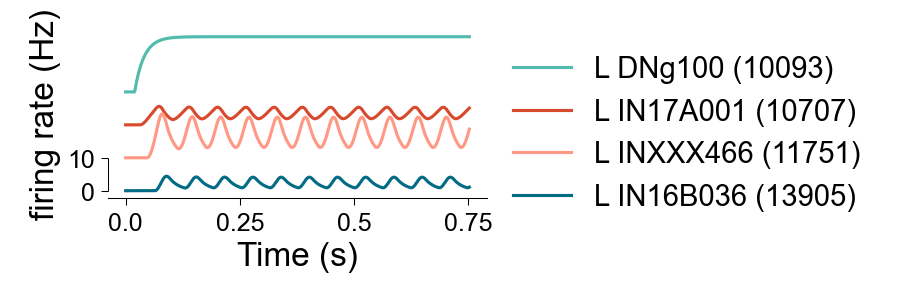

In [ ]:
idx = 901 # np.random.randint(1000)
R = Rs[idx]
spacer=10

tIdxs = np.arange(0,1000)

coreCpgData = wTable.loc[params.experiment.keepOnly]
coreCpgData.loc[31,"somaSide"] = "LHS"

plt.figure()
ax = plot_R_traces_stacked_2(R[:,:750],coreCpgData,activeOnly=True,space=spacer,colors=[dnColor,excColor,lightExcColor,inhColor])
add_tAxis(ax,0.75,3.0001)
xlimits = ax.get_xlim()
plt.vlines(xlimits[0],0,10,"k",linewidth=0.25)
plt.yticks([0,10])
plt.xlim(xlimits)
ax.spines[["left","top","right"]].set_visible(False)
ax.grid(False)
plt.ylabel("firing rate (Hz)")
fig = plt.gcf()

fig.set_figwidth(1.626)
fig.set_figheight(1.1*2/3)
fig.set_dpi(300)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+f"/dng100trace_idx{idx}.svg",transparent=True)
plt.show()

## overall data

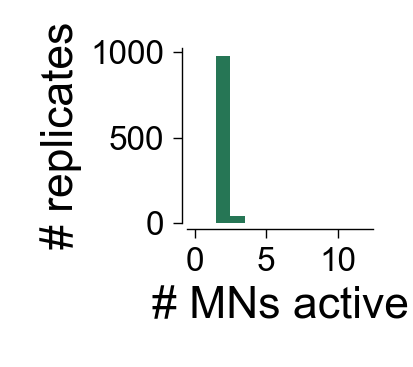

In [ ]:
plt.figure(figsize=(0.600,0.57))

ax = sns.histplot(nMnsActive,color=mnColor,edgecolor="none",binwidth=1,kde=False,alpha=1,discrete=True)

# plt.ylim([0,480])
plt.ylim([0,1024])
plt.yticks([0,500,1000])
plt.xlim([-0.5,12.5])
plt.xticks([0,5,10],labels=[0,5,10])
plt.ylabel("# replicates",fontsize=8)
plt.xlabel("# MNs active",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)
sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/activeMnHist.svg",transparent=True)
plt.show()

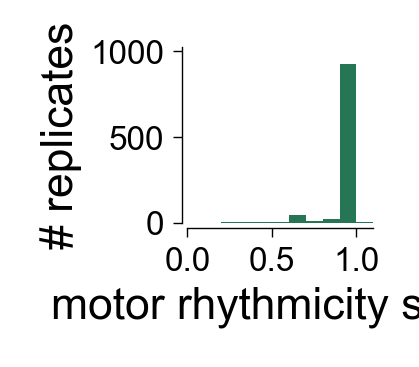

In [ ]:
plt.figure(figsize=(0.600,0.57))

ax = sns.histplot(simScore,color=mnColor,edgecolor="none",bins=np.arange(0,1.5,0.1),kde=False,alpha=1.0)
plt.xlim([0,1.1])
plt.ylim([0,1024])
plt.yticks([0,500,1000])
plt.xticks(np.arange(0,1.1,0.5))
plt.xlabel("motor rhythmicity score",fontsize=8)
plt.ylabel("# replicates",fontsize=8)
plt.gca().tick_params(axis='both', which='major', labelsize=6)
plt.gcf().set_dpi(400)

sns.despine(offset=1)

# if not os.path.exists(figFolder):
#     os.makedirs(figFolder)
# plt.savefig(figFolder+"/mnScoreHist.svg",transparent=True)
plt.show()